# Import library and Initialization

In [1]:
import src
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                             classification_report)
from sklearn.metrics import roc_auc_score, cohen_kappa_score, matthews_corrcoef, log_loss
from sklearn.multiclass import OneVsRestClassifier
from tqdm.notebook import tqdm
from sklearn.metrics import roc_curve, auc
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import label_binarize


In [2]:
tasks=[3, 5, 7, 9, 11, 13]
selectedLabels=['C3', 'C1', 'Cz', 'C2', 'C4']
features_name=['Amplitude', 'Frequency', 'Phase', 'PeakToPeak', 
                'NegativePeak', 'PositivePeak', 'Median', 'Mode', 
                'ArithmeticMean', 'RMS', 'StandardDev' ,'Summation',
                'Variance', 'Kurtoris', 'Skewness' ]
nsubject=30

# Load Data & Preprocessing & Feature Extraction

In [3]:
X,y = src.readFile_Preprocessing_ExtractFeature(tasks,selectedLabels,nsubject,42)

subject:   0%|          | 0/30 [00:00<?, ?it/s]

task:   0%|          | 0/6 [00:00<?, ?it/s]

task:   0%|          | 0/6 [00:00<?, ?it/s]

task:   0%|          | 0/6 [00:00<?, ?it/s]

task:   0%|          | 0/6 [00:00<?, ?it/s]

...

task:   0%|          | 0/6 [00:00<?, ?it/s]

task:   0%|          | 0/6 [00:00<?, ?it/s]

task:   0%|          | 0/6 [00:00<?, ?it/s]

task:   0%|          | 0/6 [00:00<?, ?it/s]

task:   0%|          | 0/6 [00:00<?, ?it/s]

In [4]:
import numpy as np
print(np.shape(X),np.shape(y))

(4140, 75) (4140,)


# Feature Selection

## TTest

In [5]:
from scipy.stats import ttest_ind

In [6]:
p_values = {feature: [] for feature in X.columns}
for feature in X.columns:
    for class_label in np.unique(y):
        class_data = X[y == class_label][feature]
        rest_data = X[y != class_label][feature]
        
        t_stat, p_value = ttest_ind(class_data, rest_data)
        p_values[feature].append(p_value)

p_values_df = pd.DataFrame(p_values, index=np.unique(y))
print("P-values for each feature and class:")
print(p_values_df)

P-values for each feature and class:
      C3_Amplitude  C3_Frequency      C3_Phase  C3_PeakToPeak  \
0.0   0.000000e+00  0.000000e+00  5.925356e-48  8.386817e-270   
1.0   1.484507e-16  3.439128e-53  3.489445e-09   3.740034e-07   
2.0   2.256872e-28  3.201455e-02  2.460380e-04   7.350415e-12   
3.0   3.891470e-37  8.093767e-86  1.179131e-04   2.245118e-15   
4.0  1.193934e-108  0.000000e+00  3.082736e-07  6.126356e-117   

     C3_NegativePeak  C3_PositivePeak     C3_Median       C3_Mode  \
0.0    2.162959e-146    2.323956e-256  1.204693e-07  7.307312e-96   
1.0     7.648215e-03     2.806793e-09  1.042430e-01  1.974043e-08   
2.0     2.150386e-07     2.020224e-11  1.018886e-01  1.881865e-08   
3.0     2.052418e-08     6.558757e-16  8.150177e-02  9.904656e-11   
4.0     1.411482e-79     2.994335e-98  7.009126e-02  2.457659e-17   

     C3_ArithmeticMean         C3_RMS  ...  C4_PositivePeak     C4_Median  \
0.0           0.041184   0.000000e+00  ...    7.859206e-267  1.094446e-07   
1.0

In [7]:
threshold = 0.05

significant_features = [
    feature for feature in X.columns 
    if any(p < threshold for p in p_values[feature])
]

print("Significant Features:", significant_features)

Significant Features: ['C3_Amplitude', 'C3_Frequency', 'C3_Phase', 'C3_PeakToPeak', 'C3_NegativePeak', 'C3_PositivePeak', 'C3_Median', 'C3_Mode', 'C3_ArithmeticMean', 'C3_RMS', 'C3_StandardDev', 'C3_Summation', 'C3_Variance', 'C3_Kurtoris', 'C3_Skewness', 'C1_Amplitude', 'C1_Frequency', 'C1_Phase', 'C1_PeakToPeak', 'C1_NegativePeak', 'C1_PositivePeak', 'C1_Median', 'C1_Mode', 'C1_RMS', 'C1_StandardDev', 'C1_Variance', 'C1_Kurtoris', 'C1_Skewness', 'Cz_Amplitude', 'Cz_Frequency', 'Cz_Phase', 'Cz_PeakToPeak', 'Cz_NegativePeak', 'Cz_PositivePeak', 'Cz_Median', 'Cz_Mode', 'Cz_RMS', 'Cz_StandardDev', 'Cz_Variance', 'Cz_Kurtoris', 'Cz_Skewness', 'C2_Amplitude', 'C2_Frequency', 'C2_Phase', 'C2_PeakToPeak', 'C2_NegativePeak', 'C2_PositivePeak', 'C2_Median', 'C2_Mode', 'C2_RMS', 'C2_StandardDev', 'C2_Variance', 'C2_Kurtoris', 'C2_Skewness', 'C4_Amplitude', 'C4_Frequency', 'C4_Phase', 'C4_PeakToPeak', 'C4_NegativePeak', 'C4_PositivePeak', 'C4_Median', 'C4_Mode', 'C4_RMS', 'C4_StandardDev', 'C4_V

In [8]:
TTest_X_selected = X[significant_features]

## ANOVA

In [9]:
from sklearn.feature_selection import f_classif

threshold = 0.05
f_scores, p_values = f_classif(np.array(X), np.array(y))
anova_results = pd.DataFrame({
    'Feature': X.columns,
    'F-score': f_scores,
    'P-value': p_values
})

print("ANOVA Results:")
print(anova_results)
significant_features_anova = anova_results[anova_results['P-value'] < threshold]['Feature']
print("Significant Features (ANOVA):", significant_features_anova.tolist())

ANOVA Results:
            Feature       F-score        P-value
0      C3_Amplitude    789.749387   0.000000e+00
1      C3_Frequency  44349.108949   0.000000e+00
2          C3_Phase     55.025963   2.863550e-45
3     C3_PeakToPeak    433.593273  1.934004e-312
4   C3_NegativePeak    225.398972  2.911719e-175
..              ...           ...            ...
70   C4_StandardDev    694.312041   0.000000e+00
71     C4_Summation      0.812491   5.169775e-01
72      C4_Variance    234.539033  9.637501e-182
73      C4_Kurtoris      7.578717   4.432207e-06
74      C4_Skewness    250.173124  1.013658e-192

[75 rows x 3 columns]
Significant Features (ANOVA): ['C3_Amplitude', 'C3_Frequency', 'C3_Phase', 'C3_PeakToPeak', 'C3_NegativePeak', 'C3_PositivePeak', 'C3_Median', 'C3_Mode', 'C3_RMS', 'C3_StandardDev', 'C3_Variance', 'C3_Kurtoris', 'C3_Skewness', 'C1_Amplitude', 'C1_Frequency', 'C1_Phase', 'C1_PeakToPeak', 'C1_NegativePeak', 'C1_PositivePeak', 'C1_Median', 'C1_Mode', 'C1_RMS', 'C1_StandardDe

In [10]:
X_anova_selected = X[significant_features_anova.tolist()]

## Mutual information

In [11]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

mi_scores = mutual_info_classif(X, y)
mi_scores = pd.Series(mi_scores, index=X.columns)
mi_scores.sort_values(ascending=False, inplace=True)
k=10
top_k_features = mi_scores.head(k).index
mi_X_selected = X[top_k_features]

# Split train and test data

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(np.array(mi_X_selected), np.array(y), test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Classification & Results

## LDA & D.T. & KNN & N.B. & SVM

models:   0%|          | 0/5 [00:00<?, ?it/s]

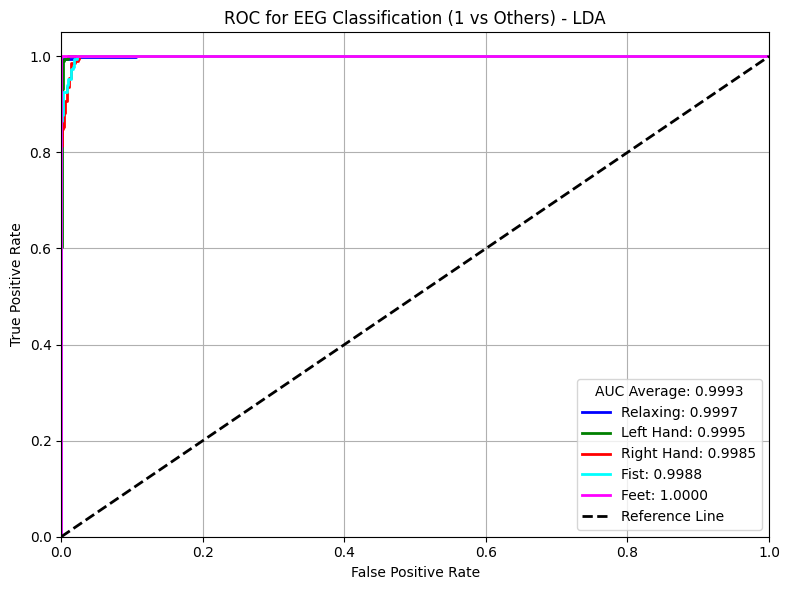

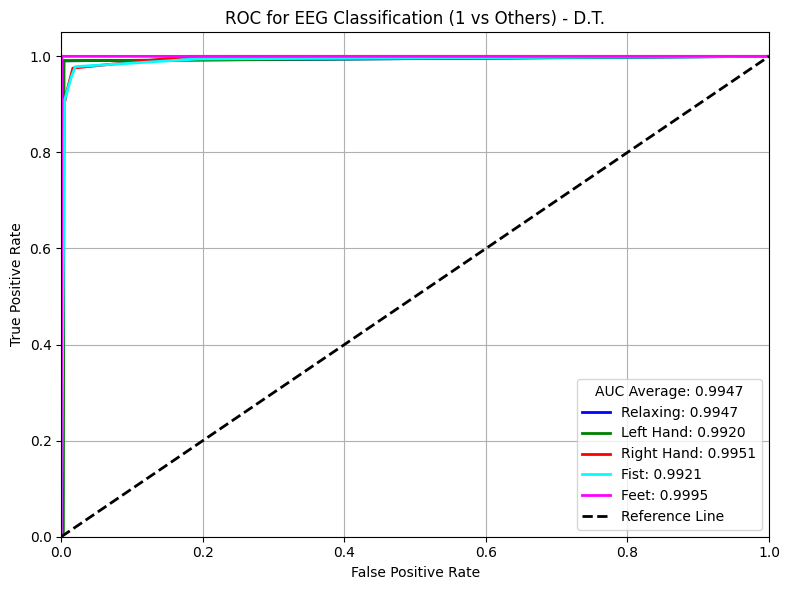

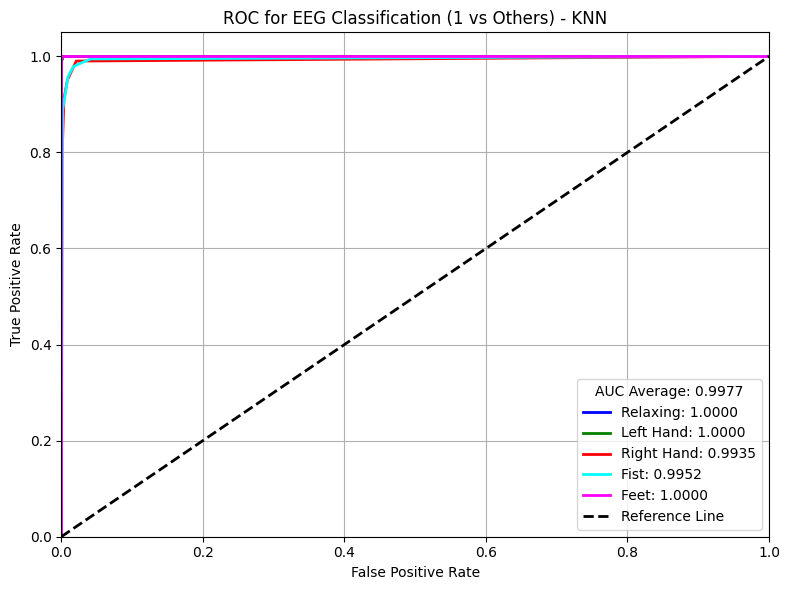

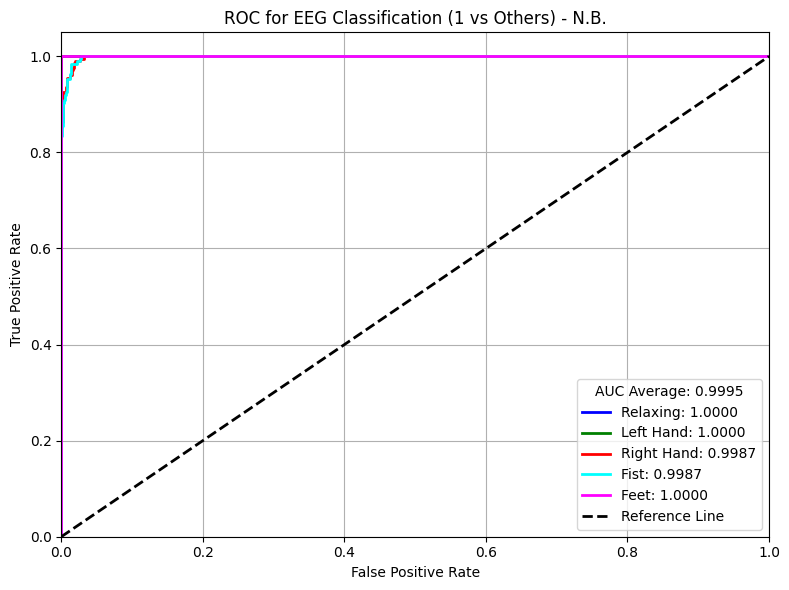

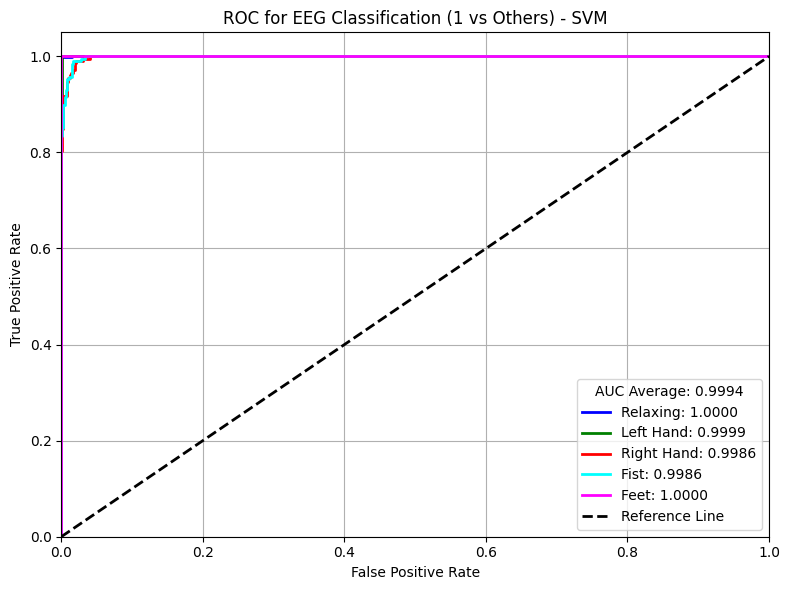

In [13]:
classifiers = {
    'LDA': LinearDiscriminantAnalysis(),
    'D.T.': DecisionTreeClassifier(random_state=42,max_depth=5),
    'KNN': KNeighborsClassifier(),
    'N.B.': GaussianNB(),
    'SVM': OneVsRestClassifier(SVC(probability=True, random_state=42)),
}

Average_Scoring = []
Performance_Metrics = []

n_classes = 5
y_test_bin = label_binarize(y_test, classes=np.arange(5))
class_names = ['Relaxing', 'Left Hand', 'Right Hand', 'Fist', 'Feet']
accuracies = []
conf_matrices = {}
errors_by_class = {}
training_times = []

for name, clf in tqdm(classifiers.items(),desc="models"):
    start_time = time.time()
    clf.fit(X_train_scaled, y_train)
    training_time = time.time() - start_time
    training_times.append(training_time)

    y_pred = clf.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    error = 1 - accuracy
    
    cm = confusion_matrix(y_test, y_pred)
    conf_matrices[name] = cm
    class_errors = 1 - cm.diagonal() / cm.sum(axis=1)
    errors_by_class[name] = class_errors

    specificity = []
    for i in range(len(cm)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity_i = tn / (tn + fp) if (tn + fp) != 0 else 0
        specificity.append(specificity_i)
    macro_specificity = np.mean(specificity)
    
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    macro_avg = report['macro avg']
    
    Average_Scoring.append({
        'ML Algorithm': name,
        'accuracy': round(accuracy, 4),
        'error': round(error, 4),
        'recall': round(macro_avg['recall'], 4),
        'specificity': round(macro_specificity, 4),
        'precision': round(macro_avg['precision'], 4),
        'f1-score': round(macro_avg['f1-score'], 4)
    })

    y_pred_prob = clf.predict_proba(X_test_scaled)
    roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
    kappa = cohen_kappa_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    loss = log_loss(y_test, y_pred_prob)
    
    Performance_Metrics.append({
        'ML Algorithm': name,
        'AUC Average': round(roc_auc, 4),
        "Cohen's Kappa Coefficient": round(kappa, 4),
        'Matthews Correlation Coefficient': round(mcc, 4),
        'logistic loss': round(loss, 4)
    })

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    avg_auc = np.mean(list(roc_auc.values()))
    
    plt.figure(figsize=(8, 6))
    colors = ['blue', 'green', 'red', 'cyan', 'magenta']
    
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{class_names[i]}: {roc_auc[i]:.4f}')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Reference Line')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC for EEG Classification (1 vs Others) - {name}')
    plt.legend(title=f'AUC Average: {avg_auc:.4f}', loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [14]:
Average_Scoring_df = pd.DataFrame(Average_Scoring)
display(Average_Scoring_df.set_index('ML Algorithm'))

,accuracy,error,recall,specificity,precision,f1-score
ML Algorithm,,,,,,
LDA,0.9767,0.0233,0.9732,0.9944,0.9719,0.9725
D.T.,0.9750,0.0250,0.9715,0.9940,0.9701,0.9700
KNN,0.9815,0.0185,0.9776,0.9956,0.9770,0.9768
N.B.,0.9831,0.0169,0.9790,0.9959,0.9792,0.9788
SVM,0.9791,0.0209,0.9748,0.9950,0.9737,0.9741


In [15]:
Performance_Metrics_df = pd.DataFrame(Performance_Metrics)
display(Performance_Metrics_df.set_index('ML Algorithm'))

,AUC Average,Cohen's Kappa Coefficient,Matthews Correlation Coefficient,logistic loss
ML Algorithm,,,,
LDA,0.9993,0.9698,0.9698,0.0591
D.T.,0.9947,0.9677,0.9680,0.2298
KNN,0.9977,0.9760,0.9762,0.1189
N.B.,0.9995,0.9781,0.9782,0.0968
SVM,0.9994,0.9729,0.9730,0.0469


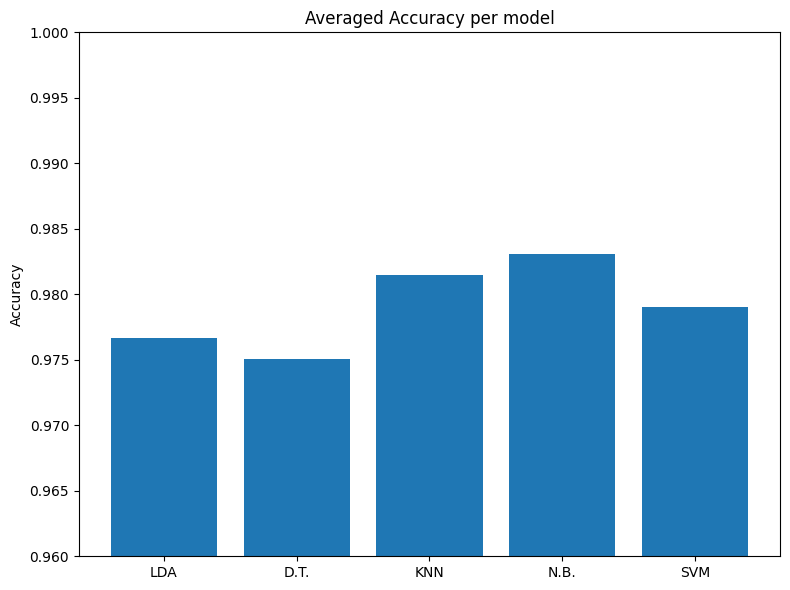

In [16]:
plt.figure(figsize=(8, 6))
plt.bar(classifiers.keys(), accuracies)
plt.title('Averaged Accuracy per model')
plt.ylabel('Accuracy')
plt.ylim(0.96, 1)
plt.tight_layout()
plt.show()

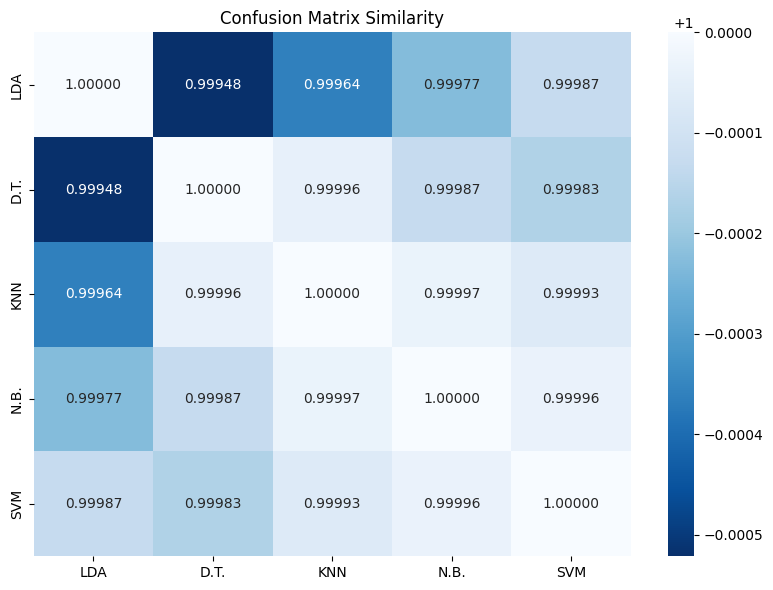

In [17]:
plt.figure(figsize=(8, 6))
flattened_cms = [conf_matrices[list(classifiers.keys())[i]].flatten() for i in range(5)]
similarity_matrix = cosine_similarity(flattened_cms)
sns.heatmap(similarity_matrix, annot=True, xticklabels=classifiers.keys(), yticklabels=classifiers.keys(), fmt=".5f",cmap="Blues_r")
plt.title('Confusion Matrix Similarity')
plt.tight_layout()
plt.show()

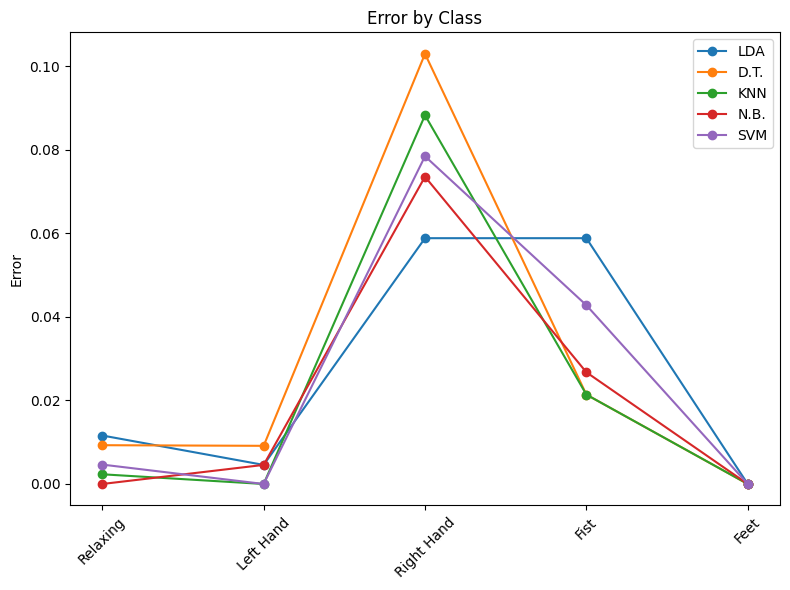

In [18]:
plt.figure(figsize=(8, 6))
for model_name, errors in errors_by_class.items():
    plt.plot(class_names, errors, marker='o', label=model_name)
plt.title('Error by Class')
plt.ylabel('Error')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

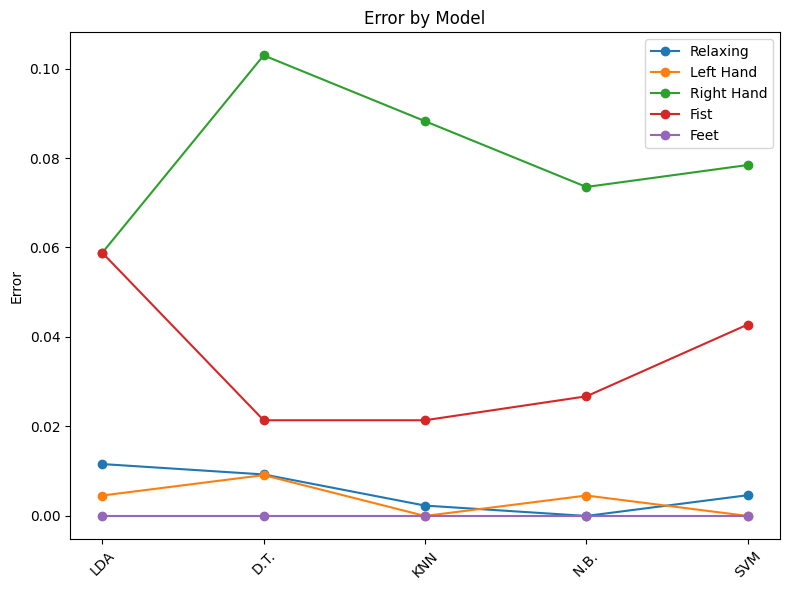

In [19]:
plt.figure(figsize=(8, 6))
for i, class_name in enumerate(class_names):
    class_errors = [errors_by_class[model][i] for model in classifiers.keys()]
    plt.plot(list(classifiers.keys()), class_errors, marker='o', label=class_name)
plt.title('Error by Model')
plt.ylabel('Error')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

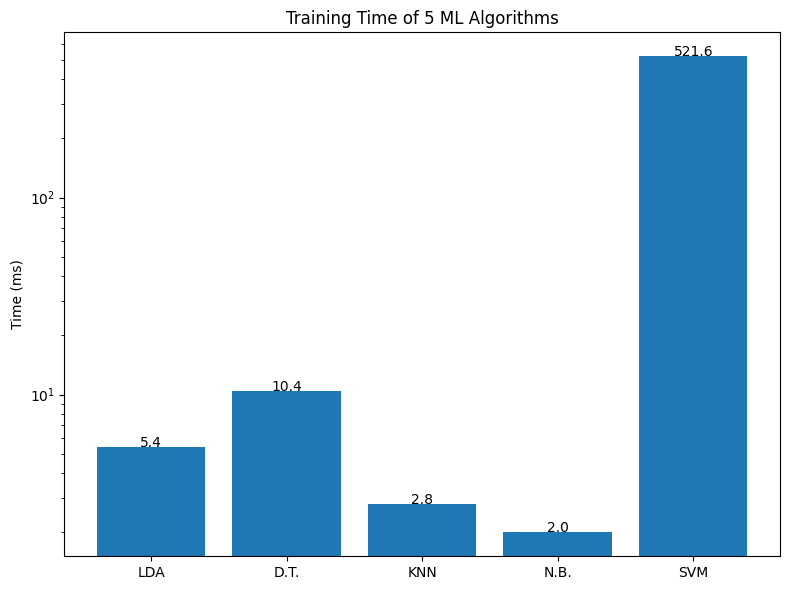

In [33]:
def addlabels(x,y):
    for i in range(len(x)):
        plt.text(i, y[i], y[i], ha = 'center')
        
plt.figure(figsize=(8, 6))
plt.bar(classifiers.keys(), np.round(training_times,4)*1000)
plt.title('Training Time of 5 ML Algorithms')
plt.ylabel('Time (ms)')
addlabels(classifiers.keys(), np.ceil(np.round(training_times,4)*10000)/10)
plt.yscale("log")
plt.tight_layout()
plt.show()